In [1]:
import jax.numpy as jnp
import jax
import numpy as np

from jax import config

config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
jax.default_backend()

'gpu'

In [3]:
np.random.seed(2)

In [4]:
def generate_gaussian_feature_matrix(n, k, theta):
    return (1 / np.sqrt(n + theta)) * jnp.asarray(np.random.randn(k, n))

In [5]:
def ReLU(z):
    return jnp.maximum(z, 0)

def Softplus(z):
    return jnp.log(1 + jnp.exp(z))

In [6]:
def data_generator(xi, gamma, m, n, theta, delta):
    A = jnp.asarray(np.random.randn(m, n))
    c = jnp.asarray(np.random.randn(m, 1))
    X = np.sqrt(theta) * c * gamma.reshape(1, n) + A
    epsilon = jnp.asarray(np.random.randn(m, 1))
    alpha = (xi.T @ gamma).item()
    y = ReLU((1 / np.sqrt(1 + theta * (alpha**2))) * X @ xi) + delta * epsilon
    return X, y

In [7]:
def loss(w, y, b, RF, l, lambd):
    return jnp.mean(l(y, RF.T@w + b)) + lambd * (jnp.linalg.norm(w) ** 2)

In [8]:
def l(y, z):
    return ((y-z)**2)

In [9]:
def least_square_estimator(y, b, RF, lambd):
    k, m = RF.shape
    w = jnp.linalg.inv(RF @ RF.T + lambd * m * jnp.eye(k)) @ RF @ (y - b)
    return w

In [10]:
z = np.random.randn(1000000)
rmu0 = ReLU(z).mean()
rmu1 = (z * ReLU(z)).mean()
rmu2 = (((z**2)-1) * ReLU(z)).mean()
rmu3 = (((z**3)-3*z) * ReLU(z)).mean()
rmus = np.sqrt((ReLU(z) ** 2).mean() - (rmu0**2) - (rmu1**2) - (1/2)*(rmu2**2) - (1/6)*(rmu3**2))
smu0 = Softplus(z).mean()
smu1 = (z * Softplus(z)).mean()
smu2 = (((z**2)-1) * Softplus(z)).mean()
smu3 = (((z**3)-3*z) * Softplus(z)).mean()
smus = np.sqrt((Softplus(z) ** 2).mean() - (smu0**2) - (smu1**2) - (1/2)*(smu2**2) - (1/6)*(smu3**2))

In [11]:
rho = 1
n = 400
k = 500
m = 500
lambd = 1e-2
delta = 0
theta = np.sqrt(n)
NB_TRIALS = 50

In [12]:
xi = np.random.randn(n, 1)
xi *= rho / np.linalg.norm(xi)

In [13]:
import gc,sys

def clear_caches():
    for module_name, module in sys.modules.items():
        if module_name.startswith("jax"):
            if module_name not in ["jax.interpreters.partial_eval"]:
                for obj_name in dir(module):
                    obj = getattr(module, obj_name)
                    if hasattr(obj, "cache_clear"):
                        try:
                            obj.cache_clear()
                        except:
                            pass
    gc.collect()

In [ ]:
def hermeval(x, c):
    if len(c) == 1:
        return c[0] * np.ones_like(x)
    elif len(c) == 2:
        return c[0] + c[1] * x
    elif len(c) == 3:
        return c[0] + c[1] * x + (1 / 2) * c[2] * ((x**2) - 1)
    elif len(c) == 4:
        return c[0] + c[1] * x + (1 / 2) * c[2] * ((x**2) - 1) + (1 / 6) * c[3] * ((x**3) - 3 * x)
    elif len(c) == 5:
        return (
            c[0]
            + c[1] * x
            + (1 / 2) * c[2] * ((x**2) - 1)
            + (1 / 6) * c[3] * ((x**3) - 3 * x)
            + (1 / 24) * c[4] * ((x**4) - 6 * (x**2) + 3)
        )
    else:
        raise NotImplementedError

r_vals = [0, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

linear_l_feature = np.zeros((len(r_vals), NB_TRIALS))
linear_gl_feature = np.zeros((len(r_vals), NB_TRIALS))
linear_l_gausssian = np.zeros((len(r_vals), NB_TRIALS))
linear_gl_gaussian = np.zeros((len(r_vals), NB_TRIALS))

cubic_l_feature = np.zeros((len(r_vals), NB_TRIALS))
cubic_gl_feature = np.zeros((len(r_vals), NB_TRIALS))
cubic_l_gaussian = np.zeros((len(r_vals), NB_TRIALS))
cubic_gl_gaussian = np.zeros((len(r_vals), NB_TRIALS))

relu_l_feature = np.zeros((len(r_vals), NB_TRIALS))
relu_gl_feature = np.zeros((len(r_vals), NB_TRIALS))
relu_l_gaussian = np.zeros((len(r_vals), NB_TRIALS))
relu_gl_gaussian = np.zeros((len(r_vals), NB_TRIALS))

Softplus_l_feature = np.zeros((len(r_vals), NB_TRIALS))
Softplus_gl_feature = np.zeros((len(r_vals), NB_TRIALS))
Softplus_l_gaussian = np.zeros((len(r_vals), NB_TRIALS))
Softplus_gl_gaussian = np.zeros((len(r_vals), NB_TRIALS))


def RFM(
    F, data, data_new, m, activation, mu0, mu1, mu2, mu3, mus, lambd=lambd, include_gaussian=False
):
    X, y = data
    X_new, y_new = data_new

    RF_feature = activation(F @ X.T)
    RF_feature_new = activation(F @ X_new.T)
    w_feature = least_square_estimator(y, 0, RF_feature, lambd)
    l_feature_ = loss(w_feature, y, 0, RF_feature, l, lambd)
    gl_feature_ = loss(w_feature, y_new, 0, RF_feature_new, l, 0)

    if include_gaussian:
        z = jnp.asarray(np.random.randn(k, m))
        z_new = jnp.asarray(np.random.randn(k, 5 * m))
        FX = F @ X.T
        FX2 = FX ** 2
        FX3 = FX ** 3
        RF_gaussian = mu0 + mu1 * FX + (1/2) * mu2 * (FX2-1) + (1/6) * mu3 * (FX3 - 3*FX) + mus * z
        FXX = F @ X_new.T
        FXX2 = FXX ** 2
        FXX3 = FXX ** 3
        RF_gaussian_new = mu0 + mu1 * FXX + (1/2) * mu2 * (FXX2-1) + (1/6) * mu3 * (FXX3 - 3*FXX) + mus * z_new
        w_gaussian = least_square_estimator(y, 0, RF_gaussian, lambd)
        l_gaussian_ = loss(w_gaussian, y, 0, RF_gaussian, l, lambd)
        gl_gaussian_ = loss(w_gaussian, y_new, 0, RF_gaussian_new, l, 0)

        return (
            l_feature_.item(),
            gl_feature_.item(),
            l_gaussian_.item(),
            gl_gaussian_.item(),
        )
    else:
        return (l_feature_.item(), gl_feature_.item())


def linear(F, data, data_new, m, lambd_=lambd):
    X, y = data
    X_new, y_new = data_new
    b = jnp.mean(y)

    def gloss(mu1_):
        RF = hermeval(F @ X.T, [0, mu1_])
        RF_new = hermeval(F @ X_new.T, [0, mu1_])
        w = least_square_estimator(y, b, RF, lambd_)
        return loss(w, y_new, b, RF_new, l, 0)

    gloss_min = float("inf")
    mu1 = 1
    for mu1_ in np.power(2.0, 10 - np.arange(20)):
        gloss_ = gloss(mu1_)
        if gloss_ < gloss_min:
            gloss_min = gloss_
            mu1 = mu1_

    RF = hermeval(F @ X.T, [0, mu1])
    w = least_square_estimator(y, b, RF, lambd_)
    mu0 = b / jnp.sum(w)

    sigma = lambda x: hermeval(x, [mu0, mu1])

    return RFM(
        F,
        data,
        data_new,
        m,
        sigma,
        mu0,
        mu1,
        0,
        0,
        0,
        lambd=lambd_,
        include_gaussian=True,
    )


def cubic(F, data, data_new, m, lambd_=lambd):
    X, y = data
    X_new, y_new = data_new
    b = jnp.mean(y)

    def gloss(mu1_, mu2_):
        RF = hermeval(F @ X.T, [0, mu1_, mu2_])
        RF_new = hermeval(F @ X_new.T, [0, mu1_, mu2_])
        w = least_square_estimator(y, b, RF, lambd_)
        return loss(w, y_new, b, RF_new, l, 0)

    gloss_min = float("inf")
    mu1 = 1
    mu2 = 0
    for mu1_ in np.power(2.0, 5 - np.arange(15)):
        for mu2_ in np.power(2.0, -np.arange(20)):
            gloss_ = gloss(mu1_, mu2_)
            if gloss_ < gloss_min:
                gloss_min = gloss_
                mu1 = mu1_
                mu2 = mu2_

    RF = hermeval(F @ X.T, [0, mu1, mu2])
    w = least_square_estimator(y, b, RF, lambd_)
    mu0 = b / jnp.sum(w)

    sigma = lambda x: hermeval(x, [mu0, mu1, mu2])

    return RFM(
        F,
        data,
        data_new,
        m,
        sigma,
        mu0,
        mu1,
        mu2,
        0,
        0,
        lambd=lambd_,
        include_gaussian=True,
    )


for e in tqdm(range(NB_TRIALS)):
    for r_i, r in enumerate(tqdm(r_vals)):
        F = generate_gaussian_feature_matrix(n, k, theta)
        g = np.random.randn(n, 1)
        gamma = r * xi + np.sqrt(1 - r**2) * (g / np.linalg.norm(g))
        data = data_generator(xi, gamma, m, n, theta, delta)
        data_new = data_generator(xi, gamma, 5*m, n, theta, delta)

        (
            linear_l_feature[r_i, e],
            linear_gl_feature[r_i, e],
            linear_l_gausssian[r_i, e],
            linear_gl_gaussian[r_i, e],
        ) = linear(F, data, data_new, m)
        (
            cubic_l_feature[r_i, e],
            cubic_gl_feature[r_i, e],
            cubic_l_gaussian[r_i, e],
            cubic_gl_gaussian[r_i, e],
        ) = cubic(F, data, data_new, m)

        (
            relu_l_feature[r_i, e],
            relu_gl_feature[r_i, e],
            relu_l_gaussian[r_i, e],
            relu_gl_gaussian[r_i, e],
        ) = RFM(
            F,
            data,
            data_new,
            m,
            ReLU,
            rmu0,
            rmu1,
            rmu2,
            rmu3,
            rmus,
            lambd=lambd,
            include_gaussian=True,
        )
        (
            Softplus_l_feature[r_i, e],
            Softplus_gl_feature[r_i, e],
            Softplus_l_gaussian[r_i, e],
            Softplus_gl_gaussian[r_i, e],
        ) = RFM(
            F,
            data,
            data_new,
            m,
            Softplus,
            smu0,
            smu1,
            smu2,
            smu3,
            smus,
            lambd=lambd,
            include_gaussian=True,
        )

        clear_caches()

In [17]:
import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault)

plt.style.use(["science", "bright"])
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times"],
        "font.size": 10,
        "figure.dpi": "600",
    }
)

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

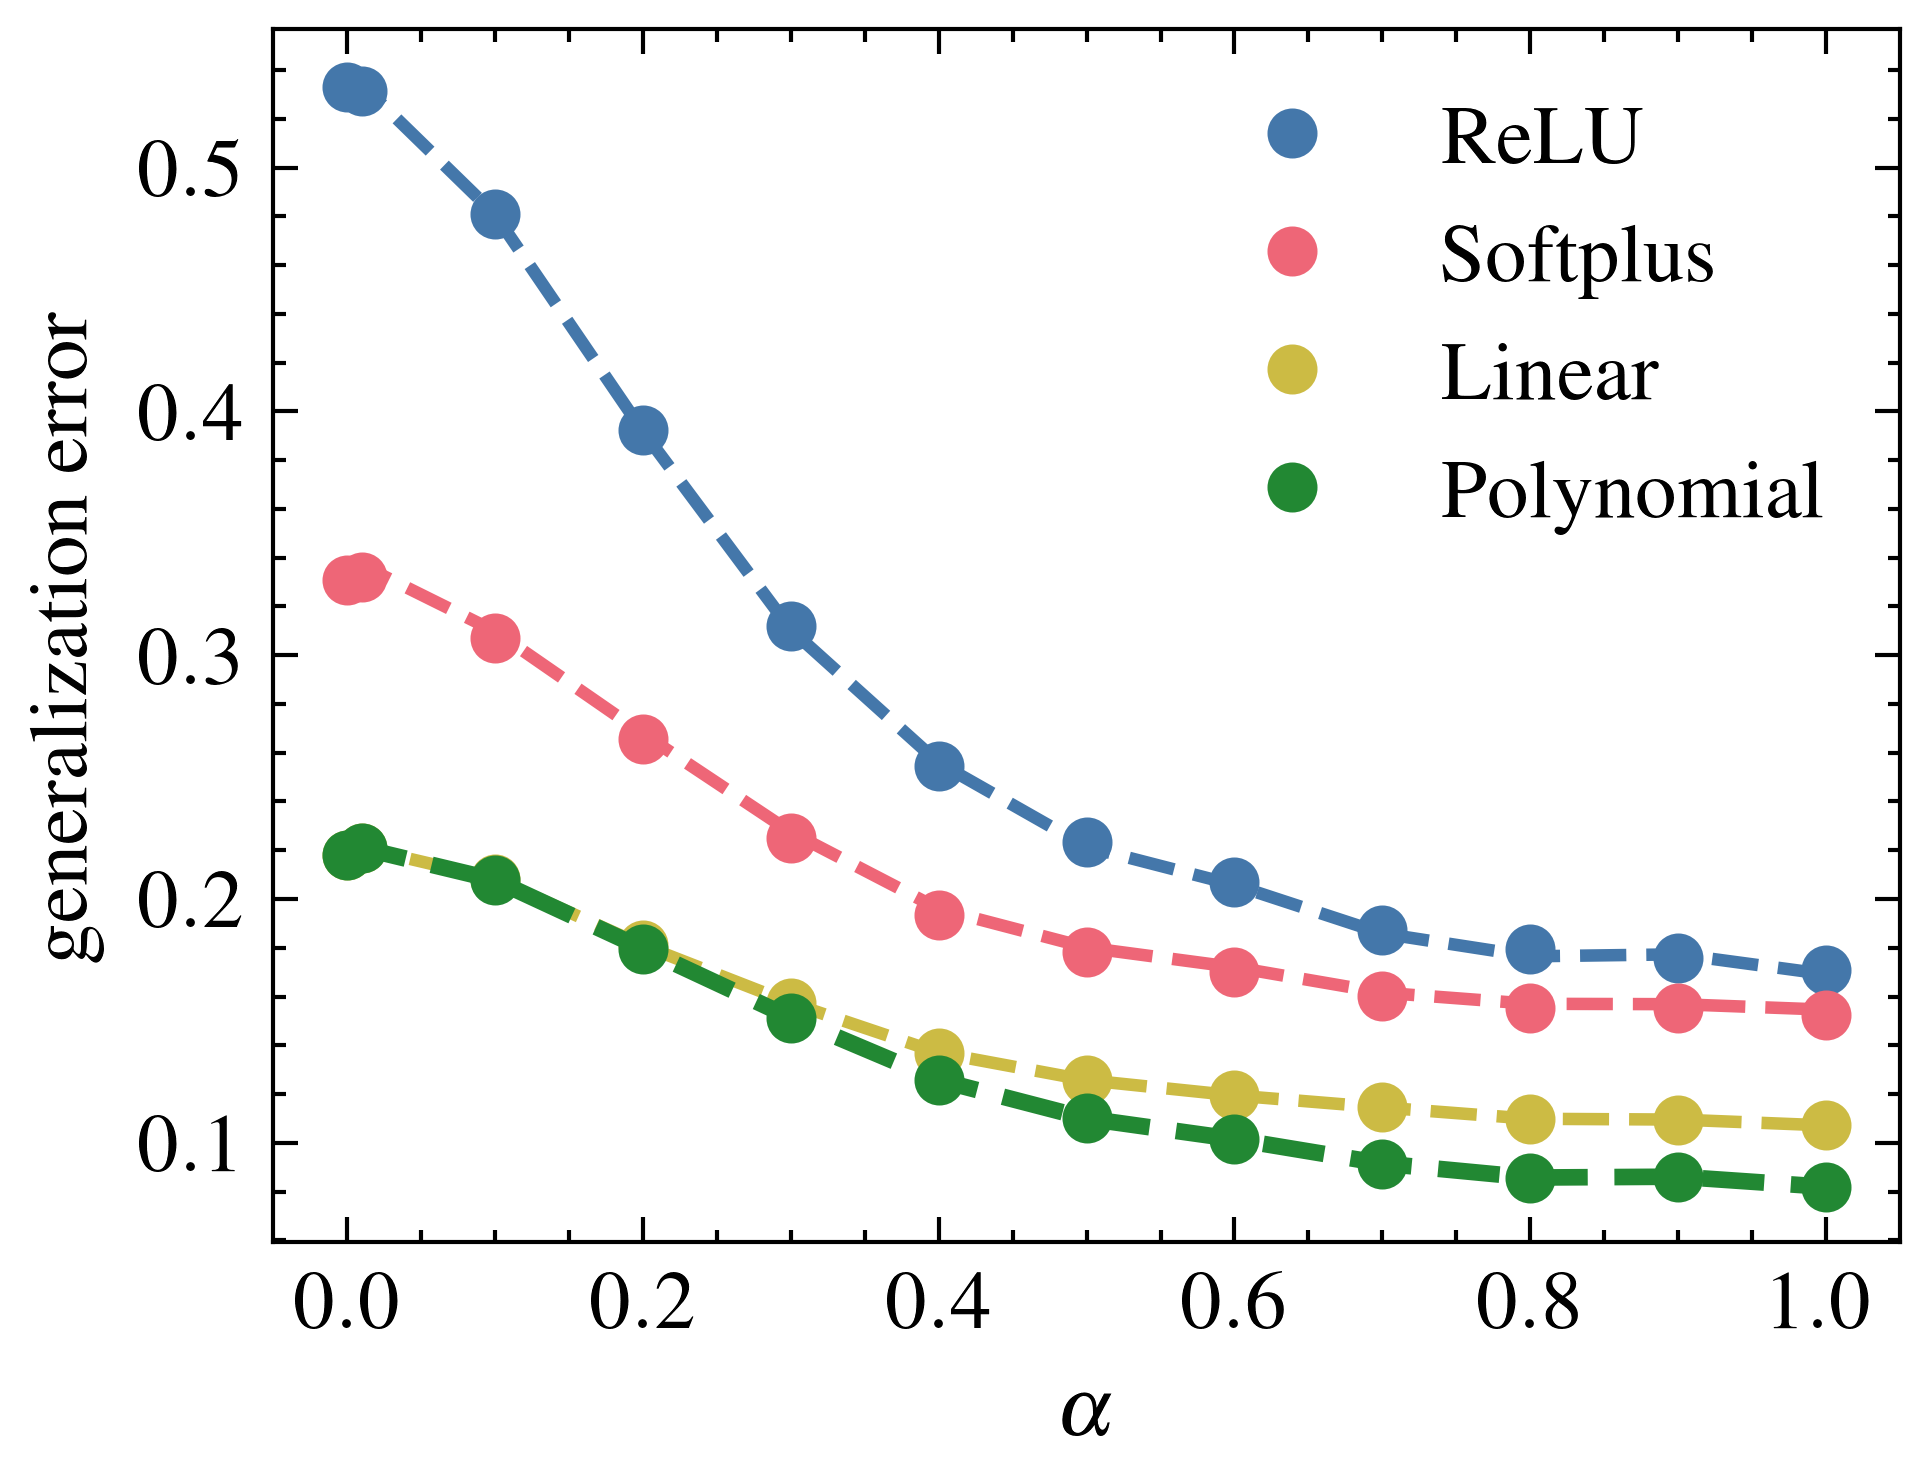

In [18]:
from matplotlib.legend_handler import HandlerTuple

plt.figure()
(relu_feature_gen,) = plt.plot(
    r_vals,
    np.mean(relu_gl_feature, axis=1),
    color=colors[0],
    linestyle="None",
    marker="o",
    markersize=5,
)
(relu_gaussian_gen,) = plt.plot(
    r_vals,
    np.mean(relu_gl_gaussian, axis=1),
    color=colors[0],
    linestyle="dashed",
    linewidth=1.5,
    label="ReLU",
)

(Softplus_feature_gen,) = plt.plot(
    r_vals,
    np.mean(Softplus_gl_feature, axis=1),
    color=colors[1],
    linestyle="None",
    marker="o",
    markersize=5,
)
(Softplus_gaussian_gen,) = plt.plot(
    r_vals,
    np.mean(Softplus_gl_gaussian, axis=1),
    color=colors[1],
    linestyle="dashed",
    linewidth=1.5,
    label="Softplus",
)

(linear_feature_gen,) = plt.plot(
    r_vals,
    np.mean(linear_gl_feature, axis=1),
    color=colors[3],
    linestyle="None",
    marker="o",
    markersize=5,
)
(linear_gaussian_gen,) = plt.plot(
    r_vals,
    np.mean(linear_gl_gaussian, axis=1),
    color=colors[3],
    linestyle="dashed",
    linewidth=1.5,
)

(cubic_feature_gen,) = plt.plot(
    r_vals,
    np.mean(cubic_gl_feature, axis=1),
    color=colors[2],
    linestyle="None",
    marker="o",
    markersize=5,
)
(cubic_gaussian_gen,) = plt.plot(
    r_vals,
    np.mean(cubic_gl_gaussian, axis=1),
    color=colors[2],
    linestyle="dashed",
    linewidth=2,
)
#plt.ylim(0, 0.25)

plt.xlabel(r"$\alpha$")
plt.ylabel(r"generalization error")
legend1 = plt.legend(
    [relu_feature_gen, Softplus_feature_gen, linear_feature_gen, cubic_feature_gen],
    ["ReLU", "Softplus", "Linear", "Polynomial"],
    loc=1,
    handler_map={tuple: HandlerTuple(ndivide=None)},
)
# legend2 = plt.legend(
#     [
#         (relu_feature_gen, Softplus_feature_gen, linear_feature_gen, cubic_feature_gen),
#         (relu_gaussian_gen, Softplus_gaussian_gen, linear_gaussian_gen, cubic_gaussian_gen),
#     ],
#     [
#         "Random Feature Model",
#         "Noisy Linear Model",
#     ],
#     loc="center left",
#     handler_map={tuple: HandlerTuple(ndivide=None)},
# )
# plt.gca().add_artist(legend1)